In [1]:
from pathlib import Path
import torch
from torch import nn
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import random

DATA_DIR   = Path("/home/rishi/medai/data/chest-xray-pneumonia/chest-pneumonia/archive/chest_xray/chest_xray")
MODEL_PATH = Path("../models/resnet18_baseline.pth")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [2]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded.")

Model loaded.


In [3]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # Forward hook captures feature maps at target layer
        target_layer.register_forward_hook(self._save_activation)
        # Backward hook captures gradients at target layer
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor):
        # Forward pass
        output = self.model(input_tensor)
        
        # Backward pass on the output logit
        self.model.zero_grad()
        output.backward()

        # Global average pool the gradients to get per-channel weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        
        # Weighted sum of feature maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)  # Only keep positive influence
        cam = cam.squeeze().cpu().numpy()

        # Normalize to 0-1
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam

In [4]:
eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

gradcam = GradCAM(model, model.layer4[-1])

def visualize_gradcam(img_path, ax_orig, ax_cam):
    # Load and preprocess image
    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = eval_tfms(img_pil).unsqueeze(0).to(device)

    # Generate heatmap
    cam = gradcam.generate(img_tensor)

    # Get model prediction
    with torch.no_grad():
        prob = torch.sigmoid(model(img_tensor)).item()
    pred = "PNEUMONIA" if prob > 0.5 else "NORMAL"

    # Resize heatmap to original image size
    img_np = np.array(img_pil.resize((224, 224)))
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Blend heatmap with original image
    overlay = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

    ax_orig.imshow(img_np, cmap="gray")
    ax_orig.set_title(f"Original\nPred: {pred} ({prob:.2f})")
    ax_orig.axis("off")

    ax_cam.imshow(overlay)
    ax_cam.set_title("Grad-CAM")
    ax_cam.axis("off")

/home/rishi/medai/projects/chest-xray-ai/.env/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


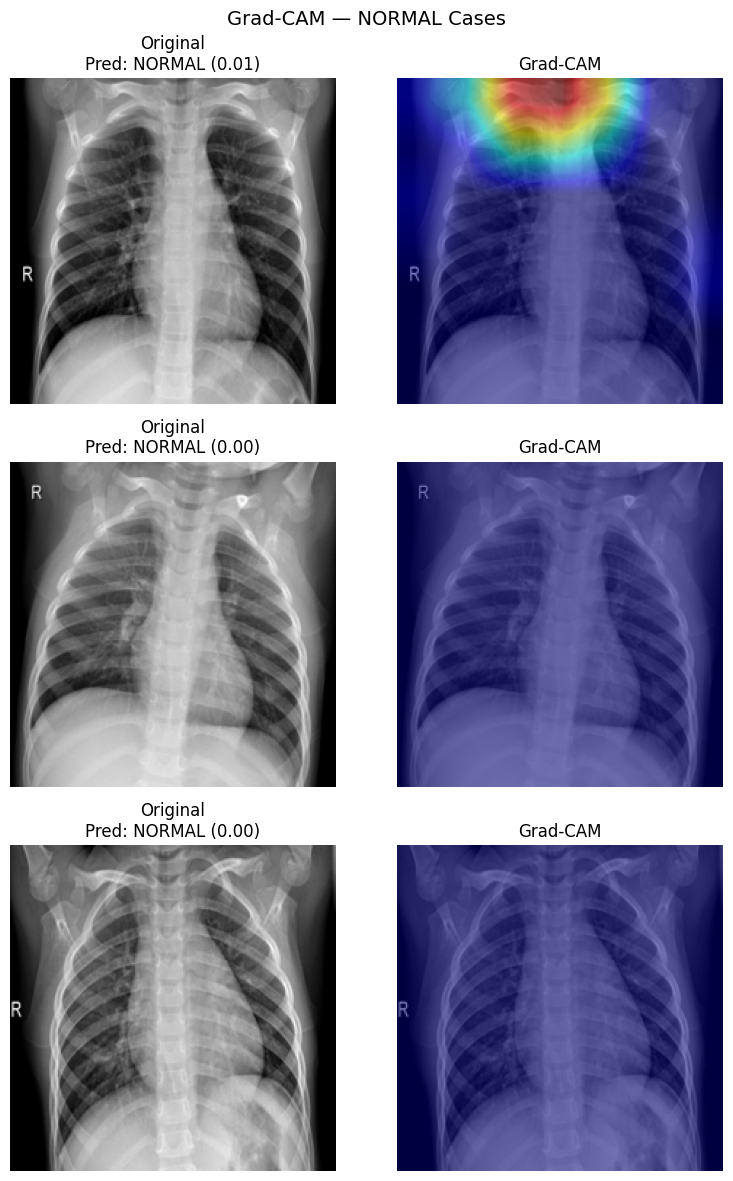

In [5]:
normal_images = list((DATA_DIR / "test" / "NORMAL").glob("*.jpeg"))
samples = random.sample(normal_images, 3)

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for i, img_path in enumerate(samples):
    visualize_gradcam(img_path, axes[i, 0], axes[i, 1])

fig.suptitle("Grad-CAM — NORMAL Cases", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/gradcam_normal.png", dpi=150, bbox_inches="tight")
plt.show()

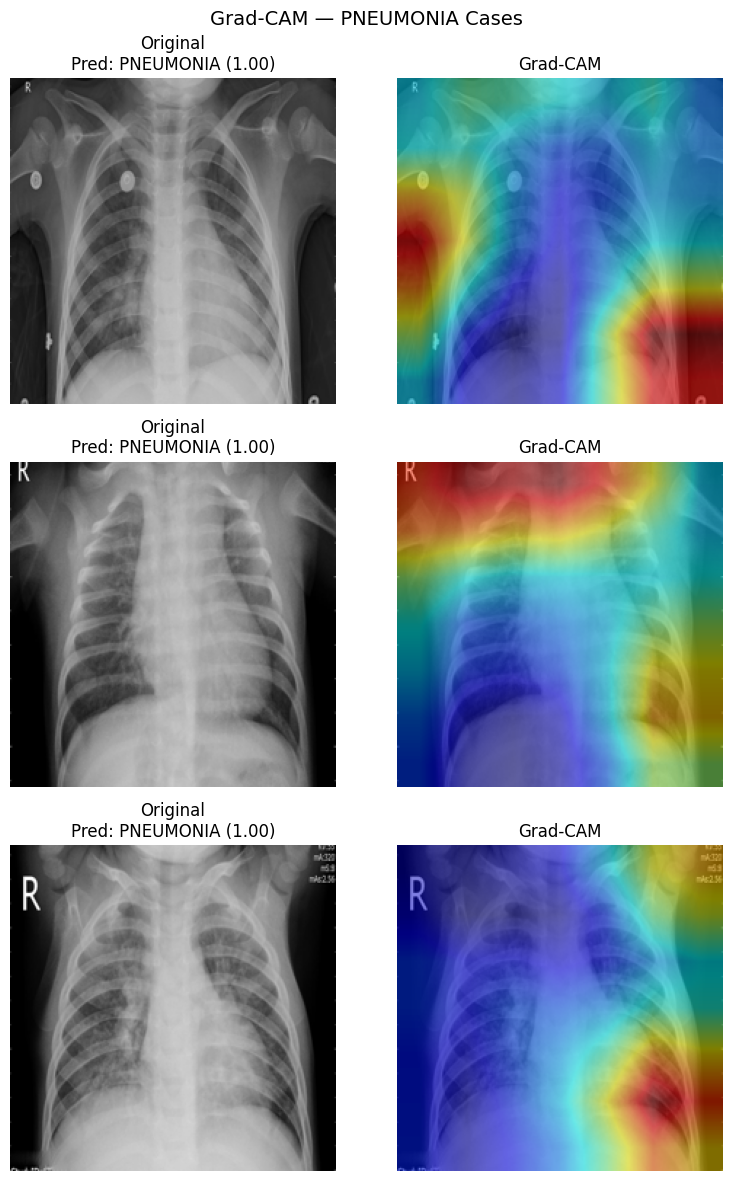

In [6]:
pneumonia_images = list((DATA_DIR / "test" / "PNEUMONIA").glob("*.jpeg"))
samples = random.sample(pneumonia_images, 3)

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for i, img_path in enumerate(samples):
    visualize_gradcam(img_path, axes[i, 0], axes[i, 1])

fig.suptitle("Grad-CAM — PNEUMONIA Cases", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/gradcam_pneumonia.png", dpi=150, bbox_inches="tight")
plt.show()